In [ ]:
# Imports
import os

# Set the JAX_PLATFORMS environment variable to "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import crawler_gym

import numpy as np
import wandb
import jax
from kandel.utility.checkpoint_loader import load_environment, load_policy
import matplotlib.gridspec as gridspec
import logging
from time import perf_counter

import matplotlib.pyplot as plt
from jax.random import randint
from numpy import ones, zeros, sum, float32, int32, logical_or
from tqdm import tqdm
from gymnasium.wrappers import RecordVideo
import matplotlib.cm as cm
import json
from pathlib import Path
from typing import Optional, Union

from omegaconf import OmegaConf

from kandel.sim_api.gymnasium import (
    generate_single_env,
    insert_normalization_params,
)
from kandel.utility.checkpoint_manager import (
    EPISODE_NAME,
)
import pandas as pd


import scienceplots  # noqa: F401

plt.style.use(["science", "grid"])

In [2]:
def fetch_config(path: Union[str, Path]):
    return OmegaConf.load(path)

In [3]:
def evaluate(
    random_key,
    # environment
    envs,
    # policy
    forward_fcn,
    update_fcn,
    policy_params,
    # timing params
    episode_steps: int,
    environment_interval: float,
    hebbian_update_interval: float,
    # logging functionality
    progress_bar: bool = False,
    # life-time logging
    record_policy: bool = False,
    record_env_info: bool = False,
    record_stepwise_rewards: bool = False,
    record_zpos: bool = True,
    # record_sensordata: bool = False,
):
    num_envs = 1
    if hasattr(envs, "num_envs"):
        num_envs = envs.num_envs

    # episode statistics
    active_episode = ones((num_envs,), dtype=int32)
    cumulative_lengths = zeros((num_envs,), dtype=int32)
    cumulative_rewards = zeros((num_envs,), dtype=float32)

    # Update management
    # Network weights are update asynchronously to forward passes.
    # The network's dynamics can be independent of environment flow.
    assert environment_interval > 0.0, (
        "Environment interaction interval must be greater than 0."
    )
    assert hebbian_update_interval > 0.0, (
        "Hebbian update interval must be greater than 0."
    )

    # floating-point operations are not reliable for tracking the frequencies,
    # therefore we transform the intervals relative to `episode_steps` to integers.
    # Episode steps define the number of simulation steps and therefore the world
    # frequency.
    total_time = episode_steps * environment_interval
    total_steps = int(
        total_time / min(environment_interval, hebbian_update_interval)
    )

    total_environment_steps = int(total_time / environment_interval)
    total_update_steps = int(total_time / hebbian_update_interval)

    relative_environment_steps = int(total_steps / total_environment_steps)
    relative_update_steps = int(total_steps / total_update_steps)

    # debug step computation
    step_compute = {
        "episode_steps": episode_steps,
        "environment_interval": environment_interval,
        "hebbian_update_interval": hebbian_update_interval,
        "total_time": total_time,
        "total_steps": total_steps,
        "total_environment_steps": total_environment_steps,
        "total_update_steps": total_update_steps,
        "relative_environment_steps": relative_environment_steps,
        "relative_update_steps": relative_update_steps,
    }
    logging.debug(step_compute)

    # initialize progress bar
    if progress_bar:
        pbar = tqdm(
            range(total_steps),
            ascii=True,
            desc="Episode steps",
            leave=False,
            position=1,
        )

    # computation time keeping
    inference_duration = 0.0
    simulation_duration = 0.0
    update_duration = 0.0

    # start environment evaluation
    seeds = randint(random_key, (num_envs,), 0, 2e15).tolist()
    if num_envs == 1:
        seeds = seeds[0]

    observations, infos = envs.reset(seed=seeds)

    # log policy parameters
    if record_policy:
        policy_params_history = [policy_params]

    # log environment information
    if record_env_info:
        environment_metrics = [infos]

    if record_stepwise_rewards:
        stepwise_rewards = []

    # if record_sensordata:
    #     sensor_data_history = []

    if record_zpos:
        z_positions = []

    # environment loop
    for time_step in range(total_steps):
        # environment and forward step
        if time_step % relative_environment_steps == 0:
            # forward step
            start_inference_duration = perf_counter()
            policy_params, actions = forward_fcn(policy_params, observations)
            inference_duration += perf_counter() - start_inference_duration

            # simulation step
            start_simulation_duration = perf_counter()
            (
                observations,
                rewards,
                terminations,
                truncations,
                infos,
            ) = envs.step(actions)

            if record_zpos:
                z_positions.append(envs.unwrapped.data.body("torso").xpos)

            simulation_duration += perf_counter() - start_simulation_duration
            dones = logical_or(terminations, truncations)

            # if record_sensordata:
            #     sensor_data_history.append(envs.sensordata)

            if record_stepwise_rewards:
                stepwise_rewards.append(rewards)

            # computing episode statistics
            # INFO: EpisodeStatistics wrapper, I have not found to be reliable
            # for evolutionary setting. Therefore a hacky solution for this.
            cumulative_lengths += active_episode
            cumulative_rewards += rewards * active_episode
            active_episode *= 1 - dones

        # update step
        if time_step % relative_update_steps == 0:
            # update step
            start_update_duration = perf_counter()
            policy_params = update_fcn(policy_params, rewards)
            update_duration += perf_counter() - start_update_duration

        # add policy parameters
        if record_policy:
            policy_params_history.append(policy_params)

        # add environment info
        if record_env_info:
            environment_metrics.append(infos)

        # update progress bar
        if progress_bar:
            pbar.update(1)

        # discontinue if all environments are done
        if sum(active_episode) == 0:
            break

    # policy: just log population parameters here. Individual metrics, like
    # partial rewards can be logged by evaluating specific populations.
    evaluation_metrics = {
        # Step statistics
        "cumulative_lengths_max": cumulative_lengths.max(),
        "cumulative_lengths_mean": cumulative_lengths.mean(),
        "cumulative_lengths_min": cumulative_lengths.min(),
        # Reward statistics
        "cumulative_rewards_max": cumulative_rewards.max(),
        "cumulative_rewards_mean": cumulative_rewards.mean(),
        "cumulative_rewards_min": cumulative_rewards.min(),
        # Time statistics
        "episode_inference_duration": inference_duration,
        "episode_simulation_duration": simulation_duration,
        "episode_update_duration": update_duration,
        "episode_avg_inference_duration": inference_duration
        / total_environment_steps,
        "episode_avg_simulation_duration": simulation_duration
        / total_environment_steps,
        "episode_avg_update_duration": update_duration / total_update_steps,
    }

    # Generate function output
    out = (
        cumulative_rewards,
        cumulative_lengths,
        evaluation_metrics,
    )

    if record_policy:
        out += (policy_params_history,)

    if record_env_info:
        out += (environment_metrics,)

    if record_stepwise_rewards:
        out += (stepwise_rewards,)

    if record_zpos:
        out += (z_positions,)

    return out

In [4]:
def check_converging_network_weights(
    network_history,
    percentage_threshold: float = 0.9,
    threshold_step: float = 0.02,
    verbose: bool = False,
):
    mse_hist = []
    layers = network_history[0]["kernel_params"].keys()

    for t in range(len(network_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = network_history[t]["kernel_params"][layer]["W"]
            params_t2 = network_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        mse_hist.append(mse)

    mse_hist = np.array(mse_hist)

    threshold = int(len(mse_hist) * threshold_step)

    avg_mse_1 = mse_hist[:threshold].mean()
    avg_mse_2 = mse_hist[threshold:].mean()

    if verbose:
        print(
            f"Average MSE 1: {avg_mse_1}, Average MSE 2: {avg_mse_2}, Threshold: {threshold}"
        )

    if avg_mse_2 * percentage_threshold < avg_mse_1:
        return True
    else:
        return False

In [5]:
def load_environment(
    checkpoint_directory: Union[str, Path],
    checkpoint: int,
    environment_id: Optional[str] = None,
    update_running_mean=False,
    **kwargs,
):
    checkpoint_directory = Path(checkpoint_directory)
    config_path = checkpoint_directory / "metadata.yaml"
    cfg = fetch_config(config_path)

    save_path = (
        checkpoint_directory
        / f"{EPISODE_NAME}_{checkpoint}"
        / "checkpoint_metadata.json"
    )

    with open(save_path, "r") as f:
        meta_data = json.load(f)

    if "environments" in cfg:
        cfg_env_id = cfg.environments[0]
    else:
        cfg_env_id = cfg.environment_id

    if environment_id is None:
        environment_id = cfg_env_id

    if cfg_env_id in meta_data:
        norm_params = meta_data[cfg_env_id]
    else:
        norm_params = meta_data

    if cfg_env_id in meta_data:
        env_params = cfg[cfg_env_id]
    else:
        env_params = cfg["gymnasium"]

    env = generate_single_env(env_id=environment_id, **env_params, **kwargs)
    env = insert_normalization_params(env, norm_params)
    env.update_running_mean = update_running_mean

    info = {
        "step_interval": cfg.step_interval,
        "update_interval": cfg.update_interval,
    }

    return env, info, cfg

In [ ]:
checkpoint_directory = "/home/alexanderdittrich/Downloads/ocarina/250420010524-halfcheetah-mlp-hebbian-adaptive-es-15"

checkpoint = 999
policy_id = 0

eval_fcn = evaluate
episode_length = 1000

seed = 11
environment_id = "ObstacleCheetah-v5"
env_kwargs = {}
viewer_resolution = (1500, 900)

obstacle_type = "single"
pendulum_mass = 50.0

# Load policies
# env, info, cfg = load_environment(
#     checkpoint_directory=checkpoint_directory,
#     checkpoint=checkpoint,
#     width=viewer_resolution[0],
#     height=viewer_resolution[1],
#     environment_id=environment_id,
#     render_mode="human",
#     **env_kwargs,
# )
video_resolution = (600, 400)
camera_id = 0
# camera_name = "side"

env, info, cfg = load_environment(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    render_mode="rgb_array",
    # width=video_resolution[0],
    # height=video_resolution[1],
    camera_id=camera_id,
    environment_id=environment_id,
    # default_camera_config=default_camera_config,
    **env_kwargs,
)

video_folder = (
    "/home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots/"
)
name_prefix = f"video_{checkpoint}_{policy_id}"
env = RecordVideo(
    env,
    video_folder=video_folder,
    name_prefix=name_prefix,
    episode_trigger=lambda x: True,
)

env.unwrapped.generate_arena(obstacle_type=obstacle_type, mass=pendulum_mass)

policy, policy_params = load_policy(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    policy_id=policy_id,
)

forward_fcn = jax.jit(policy.forward)
update_fcn = jax.jit(policy.update)
reset_fcn = policy.reset

rng = jax.random.key(seed)
rng_reset, rng_eval = jax.random.split(rng)

policy_params = reset_fcn(policy_params, rng_reset)

reward, length, _, network_hist, reward_hist, z_pos = eval_fcn(
    random_key=rng_eval,
    envs=env,
    forward_fcn=forward_fcn,
    update_fcn=update_fcn,
    policy_params=policy_params,
    episode_steps=episode_length,
    environment_interval=info["step_interval"],
    hebbian_update_interval=info["update_interval"],
    record_policy=True,
    record_stepwise_rewards=True,
)

print(f"Reward: {reward}, Length: {length}")

env.close()

check_converging_network_weights(network_hist, verbose=True)

libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
ERROR:2025-09-22 16:09:15,905:jax._src.xla_bridge:502: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 500, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)

Reward: [7546.417], Length: [1000]
Average MSE 1: 0.5970271825790405, Average MSE 2: 0.06621162593364716, Threshold: 20
Average MSE 1: 0.5970271825790405, Average MSE 2: 0.06621162593364716, Threshold: 20


True

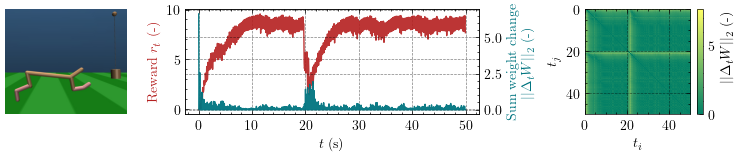

In [7]:
import matplotlib.image as mpimg

gs_kw = dict(width_ratios=[1.0, 2, 1])
fig, axs = plt.subplots(
    1, 3, figsize=(7.5, 1.55), constrained_layout=True, gridspec_kw=gs_kw
)

ts = np.arange(len(reward_hist)) * info["step_interval"]

# <------------ Step reward ------------>
axs[1].plot(ts, reward_hist, alpha=0.90, color="#B51F1F")

axs[1].set_xlabel("$t$ (s)")
axs[1].set_ylabel("Reward $r_t$ (-)", color="#B51F1F")

# <------------ MSE Plot ------------>
mse_hist = []  # should be 999
layers = network_hist[0]["kernel_params"].keys()

for t in range(len(network_hist) - 1):
    mse = 0.0
    for layer in layers:
        params_t1 = network_hist[t]["kernel_params"][layer]["W"]
        params_t2 = network_hist[t + 1]["kernel_params"][layer]["W"]
        mse += np.linalg.norm(params_t2 - params_t1)
    mse_hist.append(mse)

mse_hist = np.array(mse_hist)

t_0 = 0
t_1 = 180
t_2 = np.argmax(mse_hist[100:])
t_3 = 560

ax2 = axs[1].twinx()
ax2.plot(ts, mse_hist, alpha=0.95, color="#007480")
# ax2.set_ylim(0, 2.5)

ax2.set_ylabel(
    "Sum weight change\n" + "$||\\Delta_t W ||_2$ (-)", color="#007480"
)

# <------------ Self-similiarity ------------>
colorbar_range: tuple = (0.0, 10.0)
cmap = cm.summer

layers = list(network_hist[0]["kernel_params"].keys())
elements = list(network_hist[0]["kernel_params"][layers[0]].keys())

distance_matrix = np.zeros((episode_length, episode_length))

yvals = [ts[-1], ts[0]]
xvals = [ts[0], ts[-1]]

for i in range(episode_length):
    for j in range(episode_length):
        distance = 0.0
        for layer in layers:
            for element in elements:
                weights_i = network_hist[i]["kernel_params"][layer][element]
                weights_j = network_hist[j]["kernel_params"][layer][element]

                # Euclidian norm
                distance += np.linalg.norm(weights_i - weights_j)

        distance_matrix[i, j] = distance

heatmap = axs[2].imshow(
    distance_matrix,
    cmap=cmap,
    interpolation="nearest",
    # vmin=colorbar_range[0],
    # vmax=colorbar_range[1],
    extent=[xvals[0], xvals[1], yvals[0], yvals[1]],
)
cbar = plt.colorbar(heatmap, ax=axs[2])
cbar.set_label("$||\\Delta_t W ||_2$ (-)", loc="top")

axs[2].set_xlabel("$t_i$")
axs[2].set_ylabel("$t_j$")

start, end = axs[2].get_xlim()
axs[2].xaxis.set_ticks(np.arange(start, end, 20))


image = mpimg.imread("cheetah_perturbation.jpg")  # <-- Load your image here
axs[0].imshow(image)
axs[0].axis("off")  # No ticks for images

fig.savefig("plots/plasticity_perturbation.pdf", transparent=True)
fig.savefig("plots/plasticity_perturbation.svg", transparent=True)

plt.show()